## Imports

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.pyplot import legend

## Loading Data

In [37]:
df = pd.read_csv('resume_dataset_200k_enhanced.csv')

## Analyzing Data

In [38]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   candidate_id           200000 non-null  int64  
 1   age                    200000 non-null  int64  
 2   education_level        200000 non-null  str    
 3   university_tier        200000 non-null  str    
 4   cgpa                   200000 non-null  float64
 5   internships            200000 non-null  int64  
 6   projects               200000 non-null  int64  
 7   programming_languages  200000 non-null  int64  
 8   certifications         200000 non-null  int64  
 9   experience_years       200000 non-null  float64
 10  hackathons             200000 non-null  int64  
 11  research_papers        200000 non-null  int64  
 12  skills_score           200000 non-null  float64
 13  hired                  200000 non-null  int64  
 14  soft_skills_score      200000 non-null  float64

In [39]:
df.head()

,candidate_id,age,education_level,university_tier,cgpa,internships,projects,programming_languages,certifications,experience_years,hackathons,research_papers,skills_score,hired,soft_skills_score,resume_length_words,company_type
0,1,27,Bachelors,Tier 2,8.16,2,7,2,2,0.33,0,0,21.0,1,5.62,409,MNC
1,2,24,Bachelors,Tier 3,6.35,3,2,2,2,4.99,0,0,11.0,1,9.66,237,Startup
2,3,33,Bachelors,Tier 3,7.78,0,2,4,2,0.93,0,0,15.0,1,8.12,435,Startup
3,4,31,Masters,Tier 3,6.92,2,1,4,1,0.37,0,0,11.5,1,7.19,340,MNC
4,5,28,Masters,Tier 2,8.24,3,0,1,2,0.33,0,0,5.0,0,4.09,371,Mid-size


In [40]:
df.isnull().sum()

candidate_id             0
age                      0
education_level          0
university_tier          0
cgpa                     0
internships              0
projects                 0
programming_languages    0
certifications           0
experience_years         0
hackathons               0
research_papers          0
skills_score             0
hired                    0
soft_skills_score        0
resume_length_words      0
company_type             0
dtype: int64

In [41]:
df.duplicated().sum()

np.int64(0)

## Visualizing Data

In [42]:
df.columns

Index(['candidate_id', 'age', 'education_level', 'university_tier', 'cgpa',
       'internships', 'projects', 'programming_languages', 'certifications',
       'experience_years', 'hackathons', 'research_papers', 'skills_score',
       'hired', 'soft_skills_score', 'resume_length_words', 'company_type'],
      dtype='str')

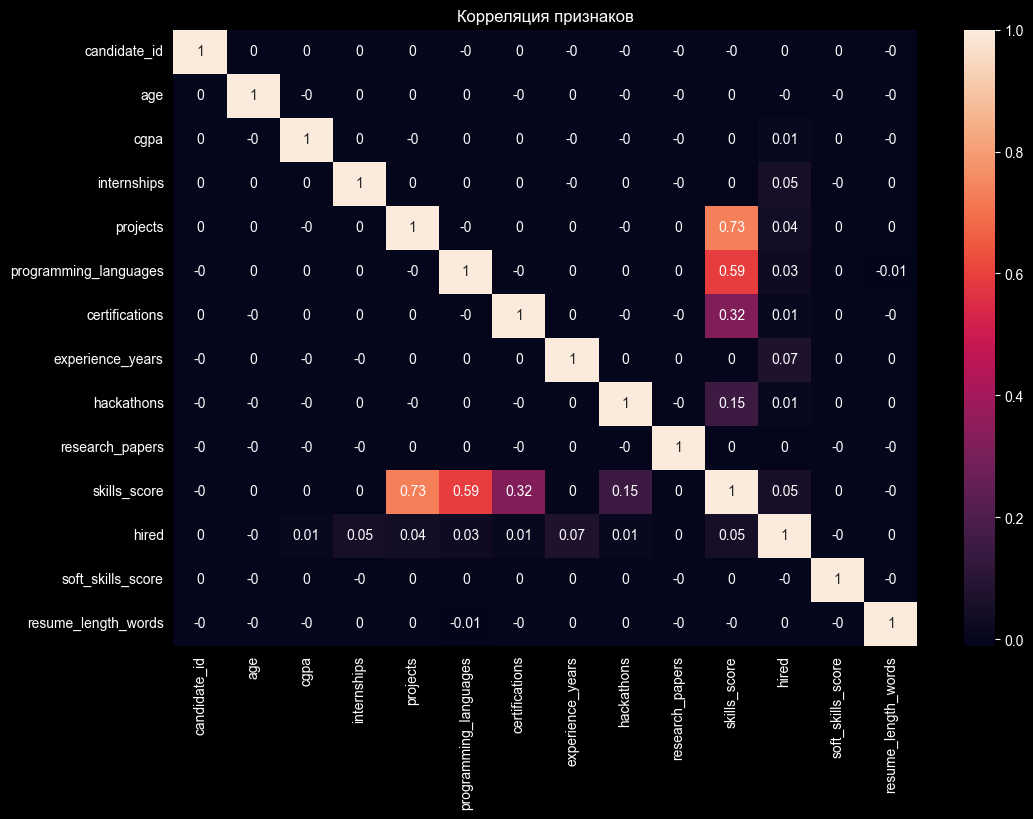

In [43]:
plt.figure(figsize=(12, 8))
plt.title('Корреляция признаков')
sns.heatmap(df.corr(numeric_only=True).round(2), annot=True)
plt.show()

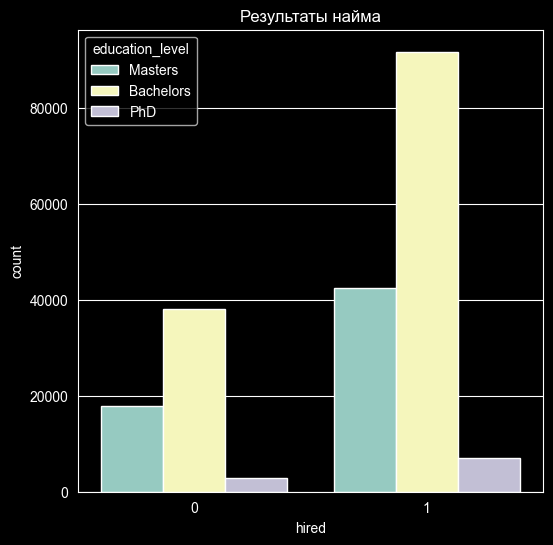

In [44]:
plt.figure(figsize=(6,6))
plt.title('Результаты найма')
sns.countplot(df, x="hired", hue="education_level")
plt.show()

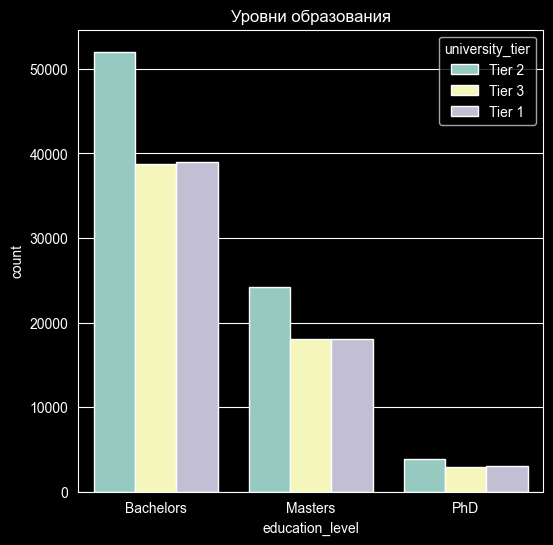

In [45]:
plt.figure(figsize=(6,6))
plt.title('Уровни образования')
sns.countplot(df, x='education_level', hue='university_tier')
plt.show()

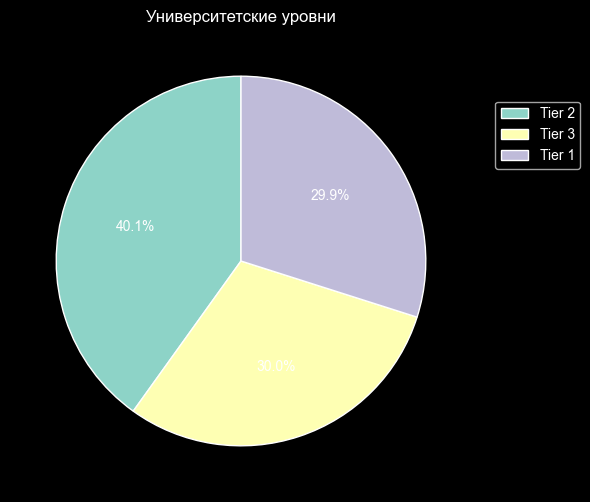

In [46]:
plt.figure(figsize=(6,6))
plt.title('Университетские уровни')
plt.pie(
    df['university_tier'].value_counts(),
    autopct='%1.1f%%',
    startangle=90
)
plt.legend(df['university_tier'].unique(), loc=(1.05, 0.7))
plt.show()

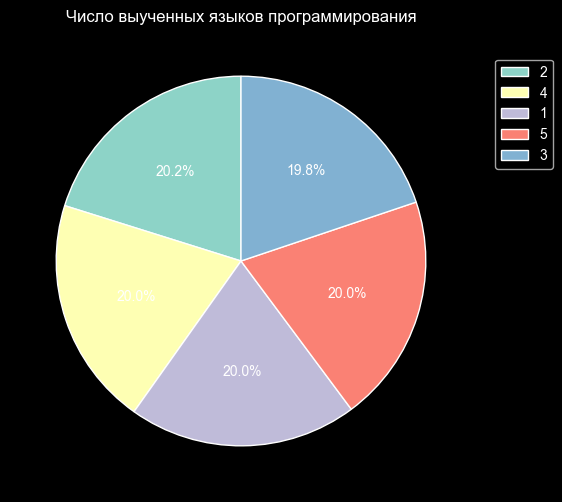

In [47]:
plt.figure(figsize=(6,6))
plt.title('Число выученных языков программирования')
plt.pie(
    df['programming_languages'].value_counts(),
    autopct='%1.1f%%',
    startangle=90
)
plt.legend(df['programming_languages'].unique(), loc=(1.05, 0.7))
plt.show()

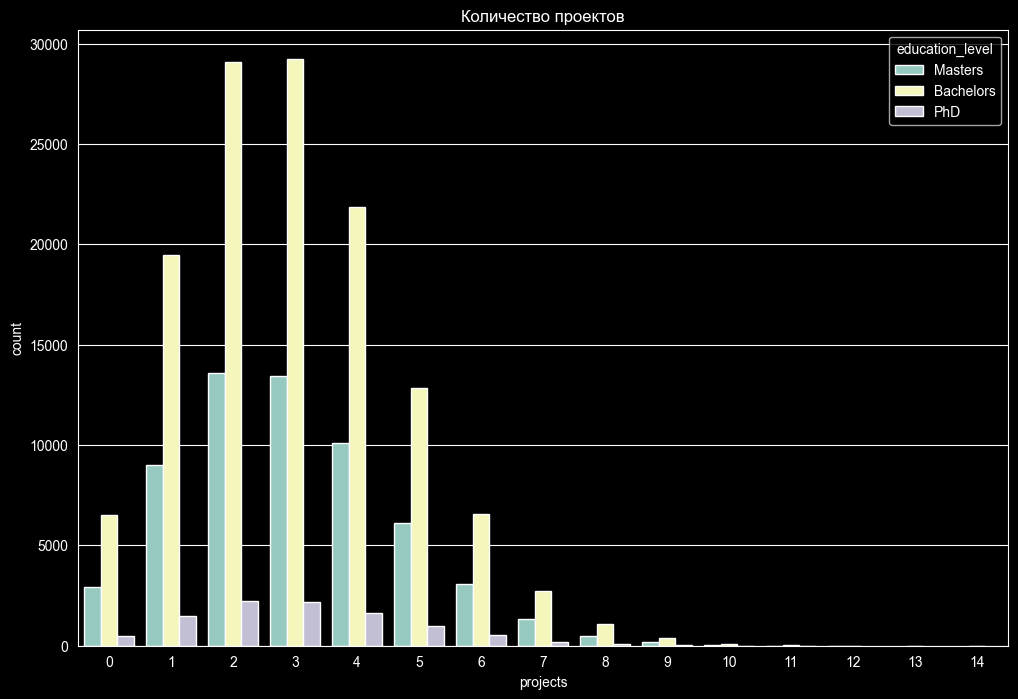

In [48]:
plt.figure(figsize=(12, 8))
plt.title('Количество проектов')
sns.countplot(df, x='projects', hue='education_level')
plt.show()

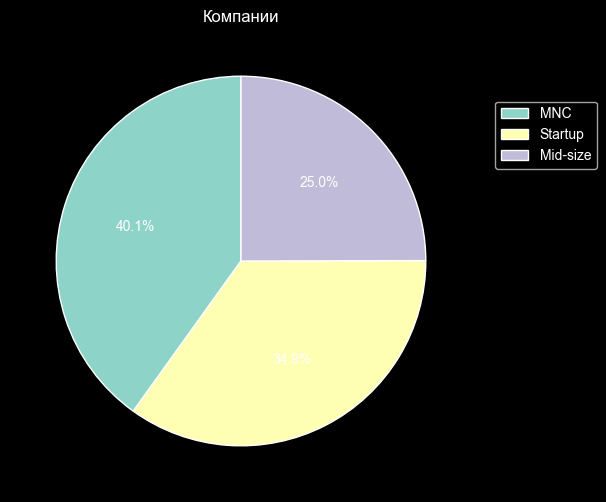

In [49]:
plt.figure(figsize=(6,6))
plt.title('Компании')
plt.pie(
    df['company_type'].value_counts(),
    autopct='%1.1f%%',
    startangle=90
)
plt.legend(df['company_type'].unique(), loc=(1.05, 0.7))
plt.show()

## Feature Engineering

### Creating new features

In [50]:
# df['balanced_skills_score'] = df['skills_score'] * df['soft_skills_score']

In [51]:
df['high_skills_score'] = ((df['skills_score'] * df['soft_skills_score']) >= 75.0).astype(int)

In [52]:
df['high_skills_score'].value_counts()

high_skills_score
1    117126
0     82874
Name: count, dtype: int64

In [53]:
df["cgpa_high"] = (df["cgpa"] >= 8.0).astype(int)

In [54]:
df['cgpa_high'].value_counts()

cgpa_high
0    146431
1     53569
Name: count, dtype: int64

### Encoding

In [55]:
cat_cols = df.select_dtypes(include='str').columns

In [56]:
cat_cols

Index(['education_level', 'university_tier', 'company_type'], dtype='str')

In [57]:
df = pd.get_dummies(df, columns=cat_cols)

### Checking Results

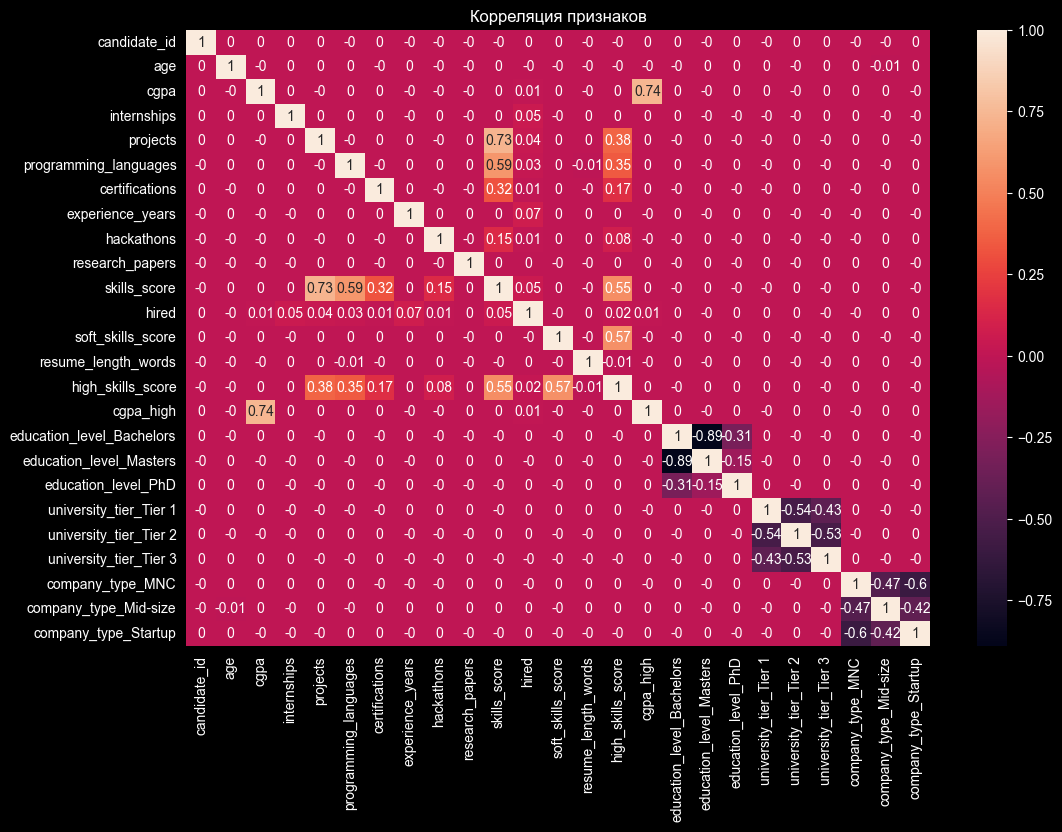

In [58]:
plt.figure(figsize=(12, 8))
plt.title('Корреляция признаков')
sns.heatmap(df.corr(numeric_only=True).round(2), annot=True)
plt.show()

## Splitting Data

In [59]:
from sklearn.model_selection import train_test_split

In [60]:
X = df.drop(columns='hired')

In [61]:
y = df['hired'].astype(int)

In [62]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

## Building Model

In [63]:
from sklearn.linear_model import LogisticRegression

In [64]:
model = LogisticRegression(max_iter=10_000, class_weight='balanced')

In [65]:
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

## Predictions

In [66]:
y_pred = model.predict(X_test)

In [67]:
y_pred

array([1, 1, 0, ..., 1, 1, 1], shape=(66000,))

## Evaluation

In [68]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [69]:
accuracy_score(y_test, y_pred)

0.5206818181818181

In [70]:
confusion_matrix(y_test, y_pred)

array([[11583,  7734],
       [23901, 22782]])